# 14주차_설명 가능 인공지능

- Preview
- 결정 트리의 설명 능력
- 설명 가능 인공지능의 수준과 어려움
- 컨볼루션 신경망의 설명 능력
- GradCAM 프로그래밍
- 참고자료

---

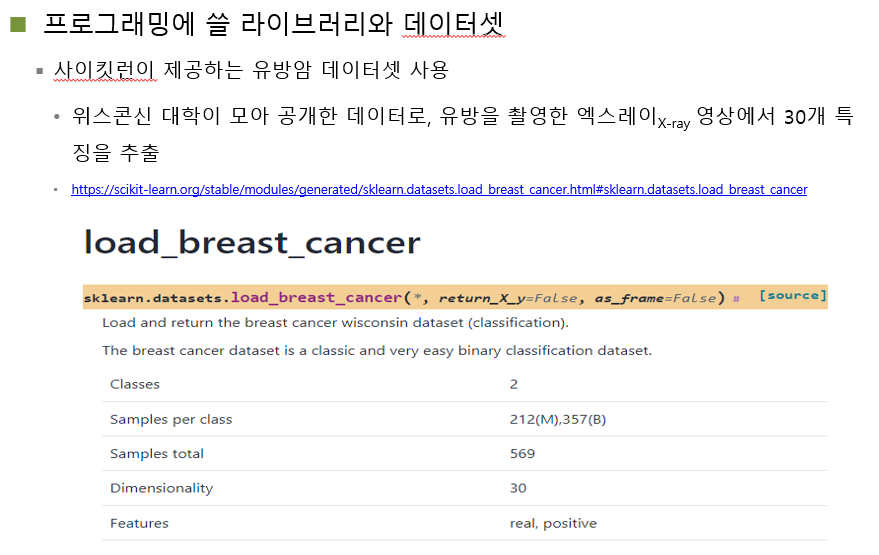

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 유방암 진단 데이터를 기반으로 하는 기초 데이터 탐색 예제임.
# sklearn의 내장 데이터셋 중 하나인 breast_cancer 데이터를 로드하고,
# 데이터에 포함된 특징(feature) 및 클래스(target) 정보를 출력함.
# 데이터 분석의 시작 단계에서 매우 중요한 **데이터 구조 파악** 및 **기본 정보 이해**를 목적으로 함.
# ------------------------------------------------------------

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: sklearn으로부터 유방암 진단 데이터 로드
# 2단계: 데이터셋 설명(descr) 출력
# 3단계: 특징 이름(feature_names) 리스트 출력
# 4단계: 클래스 이름(target_names) 리스트 출력
# ------------------------------------------------------------

from sklearn.datasets import load_breast_cancer  
# scikit-learn에서 제공하는 유방암 진단 데이터를 로드하기 위한 함수 임포트

wdbc = load_breast_cancer()  
# load_breast_cancer() 함수를 호출하여 데이터셋을 메모리에 로드하고 변수 wdbc에 저장
# wdbc는 딕셔너리와 유사한 Bunch 객체이며, 데이터/타겟/메타 정보 등을 포함함

print(wdbc.DESCR)  
# 데이터셋에 대한 전반적인 설명을 출력
# 데이터 출처, 특성 수, 클래스 정보, 사용 목적 등 메타데이터를 포함함
# 탐색적 데이터 분석(EDA)의 첫 단계에서 데이터 이해를 돕기 위한 출력 단계임

print('특징 이름=', list(wdbc.feature_names))  
# 입력 변수(피처)들의 이름을 리스트 형태로 출력
# 유방암 종양과 관련된 다양한 측정 항목(예: mean radius, texture 등)이 포함됨
# 모델링 시 어떤 피처가 사용되는지를 확인하고 분석 방향 설정에 도움을 줌

print('부류 이름=', list(wdbc.target_names))  
# 출력 변수(타겟 클래스)의 이름을 리스트 형태로 출력
# 'malignant'(악성)과 'benign'(양성) 두 가지 클래스가 존재함
# 이진 분류 문제임을 명확히 파악할 수 있게 해주는 정보 출력 단계임


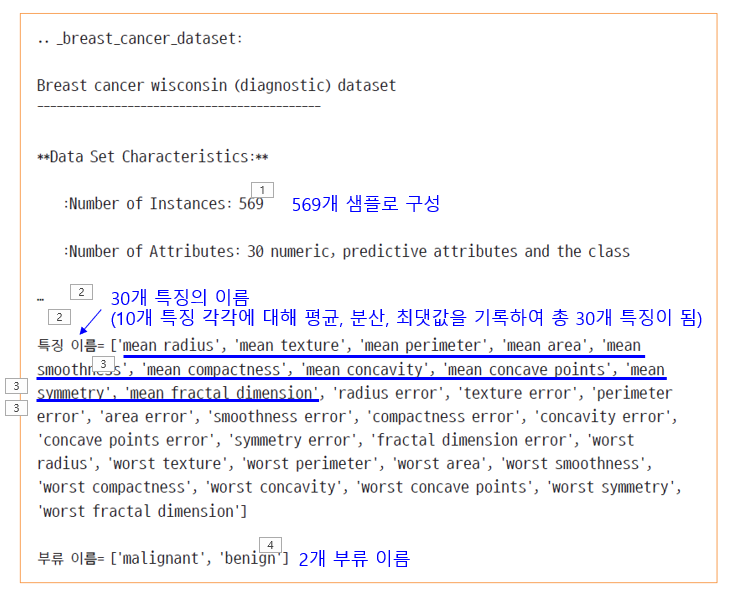

---

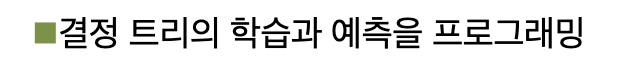

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 유방암 진단 데이터셋(Breast Cancer Wisconsin Data)을 기반으로
# 결정 트리 모델을 학습하고, 예측 정확률을 평가하며, 의사결정 트리를 시각화하는 과정을 포함함.
# 또한 특정 입력 데이터에 대해 결정 트리가 어떤 경로로 예측했는지를 시각적으로 표현함.
# Graphviz 도구를 활용하여 트리를 이미지로 저장하고, 의사결정 경로를 색상으로 강조함.
# ------------------------------------------------------------

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 데이터셋 로드 (load_breast_cancer)
# 2단계: 결정 트리 모델 학습 및 예측
# 3단계: 트리 구조 시각화 (Graphviz를 통한 .png 저장)
# 4단계: 개별 샘플에 대한 의사결정 경로 추적 및 시각화
# ------------------------------------------------------------

from sklearn.datasets import load_breast_cancer  
# 유방암 진단 데이터셋 로드를 위한 모듈 임포트

from sklearn import tree  
# 결정 트리 모델 생성 및 시각화를 위한 모듈 임포트

import pydotplus  
# Graphviz 형식의 문자열 데이터를 이미지로 변환하기 위한 시각화 도구 임포트

wdbc = load_breast_cancer()  
# 유방암 진단 데이터셋을 불러와 변수 wdbc에 저장
# wdbc는 Bunch 객체이며, 특성, 타겟, 설명 등의 정보를 포함함

decision_tree = tree.DecisionTreeClassifier(max_depth=4, random_state=1)  
# 최대 깊이 4로 제한된 결정 트리 모델 객체 생성
# random_state를 고정하여 실행 결과의 재현성을 확보함

dt = decision_tree.fit(wdbc.data, wdbc.target)  
# 학습 데이터를 이용하여 결정 트리 모델을 학습함
# wdbc.data는 피처 행렬, wdbc.target은 정답 레이블임

res = dt.predict(wdbc.data)  
# 학습 데이터 전체에 대해 예측을 수행하여 결과를 res에 저장함

print('결정 트리의 정확률=', sum(res == wdbc.target) / len(res))  
# 예측 결과와 실제 타겟 레이블을 비교하여 정확률을 산출함
# 전체 샘플 중 일치하는 비율을 통해 학습 데이터에 대한 성능을 확인함

dot = tree.export_graphviz(  
    dt,  
    out_file=None,  
    feature_names=wdbc.feature_names,  
    class_names=wdbc.target_names,  
    filled=True,  
    node_ids=True,  
    rounded=True  
)  
# 결정 트리 모델을 Graphviz 포맷의 문자열(dot 언어)로 변환함
# 노드를 색칠하고, 노드 ID를 부여하며, 모서리를 둥글게 표현함

graph = pydotplus.graph_from_dot_data(dot)  
# dot 형식 문자열을 pydotplus를 통해 그래프 객체로 변환함

import os  
# 환경변수 설정을 위해 os 모듈을 임포트함

os.environ['PATH'] = os.environ['PATH'] + ';' + os.environ['CONDA_PREFIX'] + r"\Library\bin\graphviz"  
# Graphviz 실행 파일 경로를 시스템 PATH 환경변수에 추가함
# Windows 환경에서 Graphviz 실행 경로를 명시적으로 지정하기 위한 설정임

graph.write_png('tree.png')  
# 생성한 결정 트리 그래프를 'tree.png' 이미지 파일로 저장함

x_test = wdbc.data[0:1]  
# 첫 번째 샘플 데이터만 선택하여 의사결정 경로 추적 대상으로 지정함

path = dt.decision_path(x_test)  
# 지정된 입력값 x_test에 대해 결정 트리에서 어떤 노드를 거쳐 예측이 이루어졌는지 경로를 반환함
# 반환 결과는 희소 행렬(sparse matrix) 형태임

print(path)  
# 결정 경로에 해당하는 희소 행렬 정보를 출력함

path_seq = path.toarray()[0]  
# 희소 행렬을 일반 배열로 변환하고 첫 번째 행만 추출하여 사용함
# 각 노드가 방문되었는지를 나타내는 0 또는 1의 값으로 구성된 배열임

print(path_seq)  
# 각 노드의 방문 여부(0 또는 1)를 출력함
# 1이면 해당 노드를 경유한 것이며, 0이면 경유하지 않음을 의미함

for n, value in enumerate(path_seq):  
    node = graph.get_node(str(n))[0]  
    # n번째 노드 ID에 해당하는 그래프 노드를 가져옴
    if value == 0:  
        node.set_fillcolor('white')  
        # 경로에 포함되지 않은 노드는 흰색으로 설정함
    else:  
        node.set_fillcolor('green')  
        # 경로에 포함된 노드는 초록색으로 설정함
        # 이를 통해 특정 입력이 결정 트리에서 어떤 경로를 따라 분류되었는지를 시각적으로 표현함

graph.write_png('tree_with_path.png')  
# 의사결정 경로가 색상으로 표시된 트리를 이미지로 저장함
# 파일 이름은 'tree_with_path.png'로 지정됨


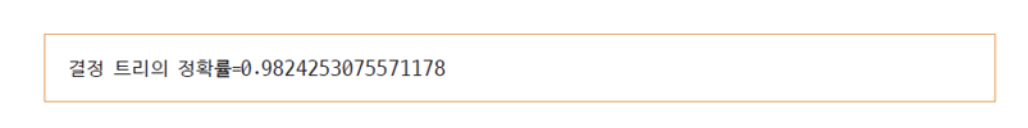

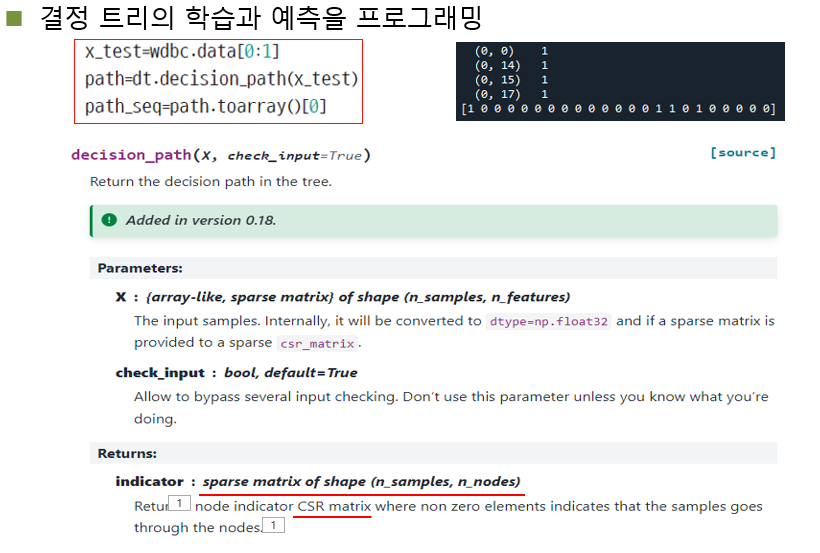

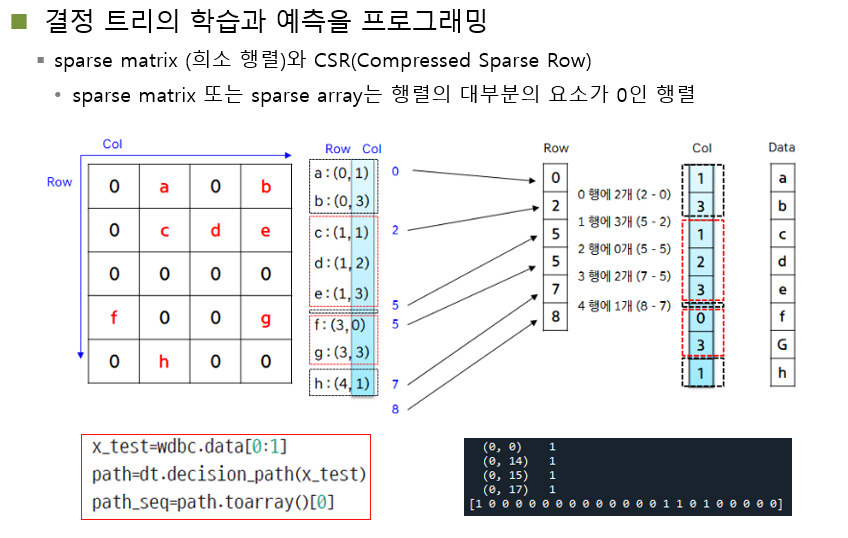

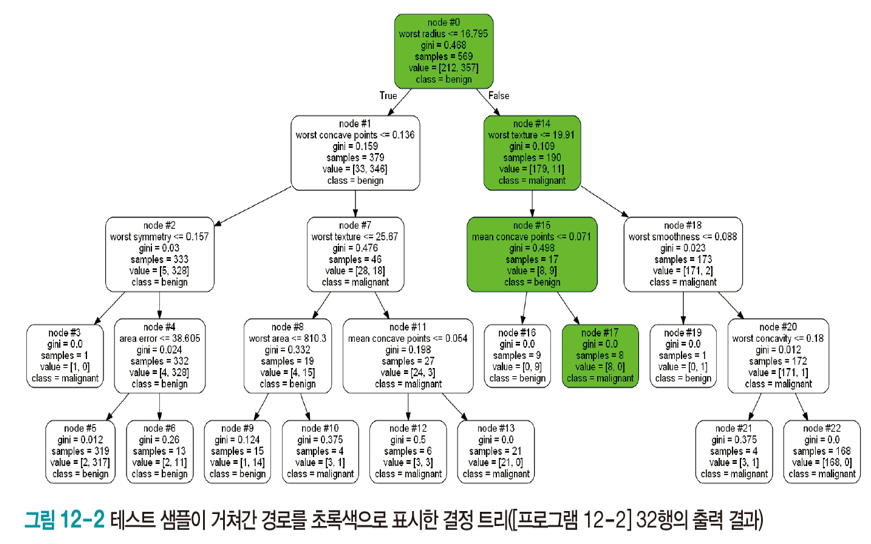

---


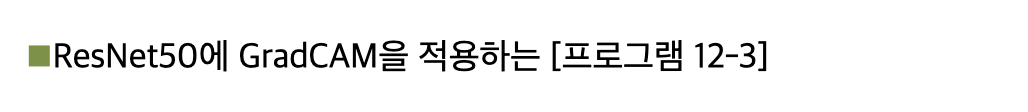

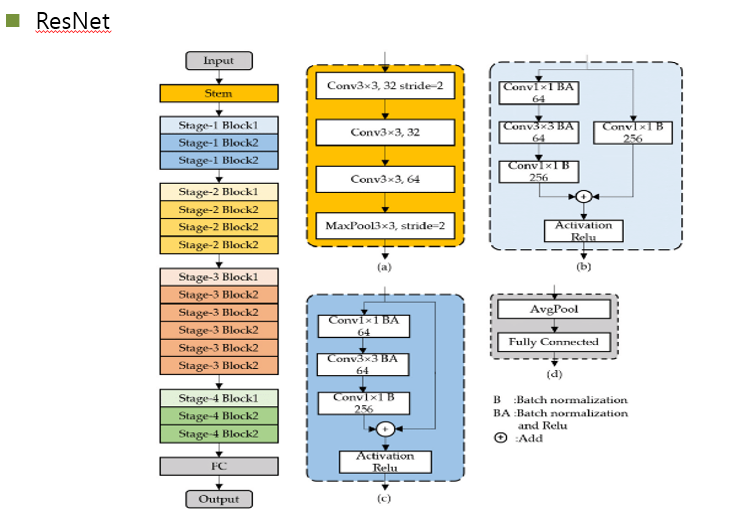

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 사전 학습된 ResNet50 신경망을 활용하여 이미지 분류를 수행하고,
# Grad-CAM(Gradient-weighted Class Activation Mapping)을 이용해 예측에 기여한 영역을 시각화함.
# 모델 분리, 그레이디언트 계산, 히트맵 생성 및 원본 이미지 위에 오버레이하는 과정을 포함함.
# 이를 통해 딥러닝 모델의 결정 근거를 시각적으로 해석할 수 있는 설명 가능한 인공지능(XAI) 예제임.
# ------------------------------------------------------------

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 라이브러리 임포트 및 모델 로드
# 2단계: 입력 이미지 불러오기 및 전처리
# 3단계: 이미지 분류 및 예측 결과 출력
# 4단계: 모델 분리 (특징 추출부 vs 분류부)
# 5단계: Grad-CAM 계산
# 6단계: 히트맵 시각화 및 입력 이미지에 오버레이
# ------------------------------------------------------------

# ------------------------------------------------------------
# [1단계] 라이브러리 임포트 및 모델 로드
# ------------------------------------------------------------

import numpy as np  
# 수치 연산 및 배열 처리를 위한 NumPy 모듈 임포트

import tensorflow as tf  
# 텐서 기반 연산 및 딥러닝 기능 제공을 위한 TensorFlow 모듈 임포트

from tensorflow import keras  
# 케라스 고수준 API 임포트

from tensorflow.keras.applications import resnet50, ResNet50  
# 사전 학습된 ResNet50 모델 및 관련 전처리, 디코딩 유틸리티 임포트

from tensorflow.keras.preprocessing import image  
# 이미지 로딩 및 전처리 기능 제공 모듈 임포트

import matplotlib.pyplot as plt  
# 시각화를 위한 Matplotlib 라이브러리 임포트

import matplotlib.cm as cm  
# 컬러맵 시각화를 위한 컬러 매핑 유틸리티 임포트

model = ResNet50(weights='imagenet')  
# ImageNet으로 학습된 사전 학습 모델 ResNet50 로드

model.summary()  
# 모델 구조 요약 출력 (층 구조 및 파라미터 수 확인용)

# ------------------------------------------------------------
# [2단계] 입력 이미지 불러오기 및 전처리
# ------------------------------------------------------------

image_path = './hummingbird.jpg'  
# 입력 이미지 파일 경로 지정

img = image.load_img(image_path, target_size=(224, 224))  
# 지정한 이미지를 224x224로 크기 조정하여 로드

plt.matshow(img)  
# 이미지를 행렬 형식으로 시각화하여 출력

x = image.img_to_array(img)  
# 이미지를 넘파이 배열로 변환 (형태: H×W×C)

x = np.expand_dims(x, axis=0)  
# 배치 차원을 추가하여 신경망 입력 형태로 변환 (1×224×224×3)

x = resnet50.preprocess_input(x)  
# ResNet50 모델에 맞는 전처리 적용 (픽셀 정규화 및 색상 스케일 변환)

# ------------------------------------------------------------
# [3단계] 이미지 분류 및 예측 결과 출력
# ------------------------------------------------------------

preds = model.predict(x)  
# 입력 이미지를 모델에 통과시켜 클래스별 확률 예측

print("예측 결과:", resnet50.decode_predictions(preds, top=5)[0])  
# 예측된 확률 중 상위 5개의 클래스명을 해석하여 출력

# ------------------------------------------------------------
# [4단계] 모델 분리 (특징 추출부 vs 분류부)
# ------------------------------------------------------------

last_conv_layer = model.get_layer("conv5_block3_out")  
# 마지막 합성곱 층(conv5_block3_out)을 가져옴 (Grad-CAM 대상 층)

model_1 = keras.Model(model.inputs, last_conv_layer.output)  
# 특징 추출부만 따로 구성된 모델 정의

input_2 = keras.Input(shape=last_conv_layer.output.shape[1:])  
# 분류부 입력으로 사용할 텐서 정의

x_2 = model.get_layer("avg_pool")(input_2)  
# 전역 평균 풀링 층 연결

x_2 = model.get_layer("predictions")(x_2)  
# 최종 softmax 출력층 연결

model_2 = keras.Model(input_2, x_2)  
# 분류부만 따로 구성된 모델 정의

# ------------------------------------------------------------
# [5단계] Grad-CAM 계산
# ------------------------------------------------------------

with tf.GradientTape() as tape:  
    output_1 = model_1(x)  
    # 입력을 특징 추출부에 통과시켜 마지막 conv 층의 출력 획득
    tape.watch(output_1)  
    # output_1에 대해 그레이디언트를 추적함
    preds = model_2(output_1)  
    # 특징 맵을 분류기에 통과시켜 클래스별 확률 획득
    class_id = tf.argmax(preds[0])  
    # 예측된 클래스 중 가장 높은 확률을 가진 인덱스를 class_id로 저장
    output_2 = preds[:, class_id]  
    # 해당 클래스의 예측 확률값을 선택함

grads = tape.gradient(output_2, output_1)  
# 예측 결과에 대한 마지막 conv 층 출력의 gradient 계산

pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))  
# 채널별 평균 그레이디언트를 계산하여 중요도를 추출함 (식 12.5)

output_1 = output_1.numpy()[0]  
# 텐서를 넘파이 배열로 변환하고 배치 차원을 제거함

pooled_grads = pooled_grads.numpy()  
# 중요도 벡터를 넘파이 배열로 변환

for i in range(pooled_grads.shape[-1]):  
    output_1[:, :, i] *= pooled_grads[i]  
    # 각 채널의 특징 맵에 해당 채널의 중요도를 곱하여 가중합 계산 (식 12.6)

heatmap = np.mean(output_1, axis=-1)  
# 모든 채널에 대해 평균을 내어 최종 heatmap 생성

heatmap = np.maximum(heatmap, 0) / np.max(heatmap)  
# 음수 제거 및 정규화를 통해 [0,1] 범위의 히트맵 생성

plt.matshow(heatmap)  
# 생성된 히트맵을 시각화하여 출력

# ------------------------------------------------------------
# [6단계] 히트맵 시각화 및 입력 이미지에 오버레이
# ------------------------------------------------------------

img = image.load_img(image_path)  
# 원본 이미지를 다시 불러옴 (224x224로 축소되지 않은 버전)

img = image.img_to_array(img)  
# 이미지를 배열로 변환

heatmap = np.uint8(255 * heatmap)  
# 히트맵을 0~255 범위의 정수형으로 변환

jet = cm.get_cmap("jet")  
# jet 컬러맵을 사용하여 색상 변환을 준비함

color = jet(np.arange(256))[:, :3]  
# 0~255 범위의 색상 배열을 생성 (RGB만 추출)

color_heatmap = color[heatmap]  
# 히트맵 값을 색상에 매핑하여 RGB 히트맵 생성

color_heatmap = keras.preprocessing.image.array_to_img(color_heatmap)  
# 색상 히트맵을 PIL 이미지 객체로 변환

color_heatmap = color_heatmap.resize((img.shape[1], img.shape[0]))  
# 히트맵 크기를 원본 이미지와 동일하게 조정

color_heatmap = keras.preprocessing.image.img_to_array(color_heatmap)  
# PIL 이미지를 배열로 다시 변환

overlay_img = color_heatmap * 0.4 + img  
# 원본 이미지와 히트맵을 혼합하여 오버레이 생성 (투명도 40%)

overlay_img = keras.preprocessing.image.array_to_img(overlay_img)  
# 최종 오버레이 이미지를 PIL 형식으로 변환

plt.matshow(overlay_img)  
# 오버레이 이미지를 시각화하여 출력


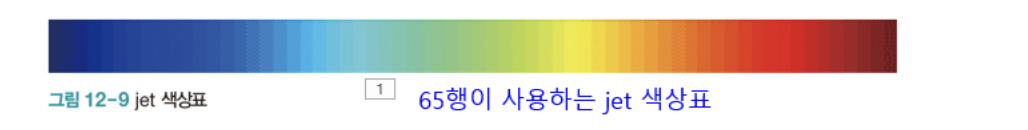

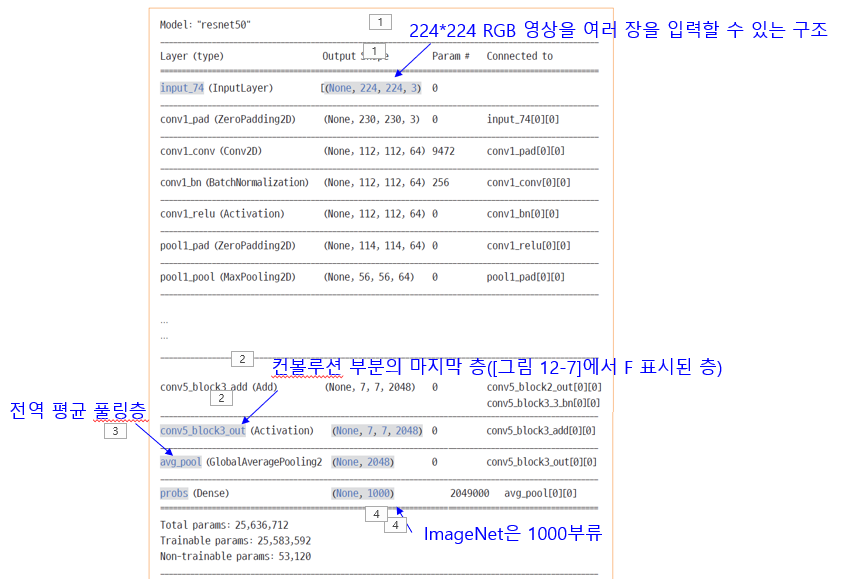

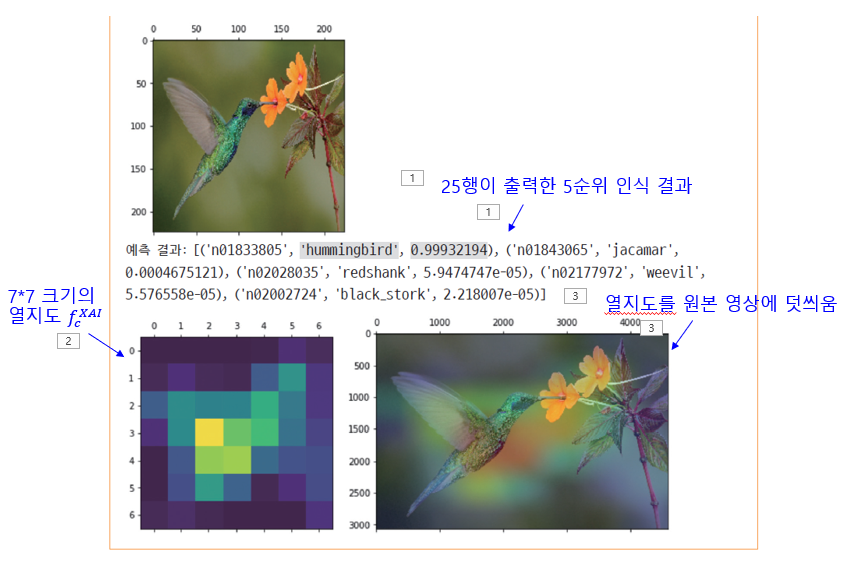

---

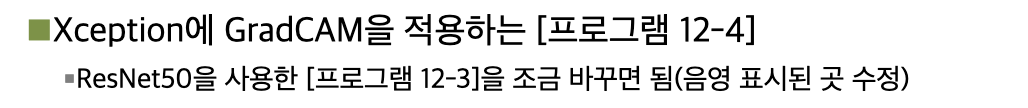

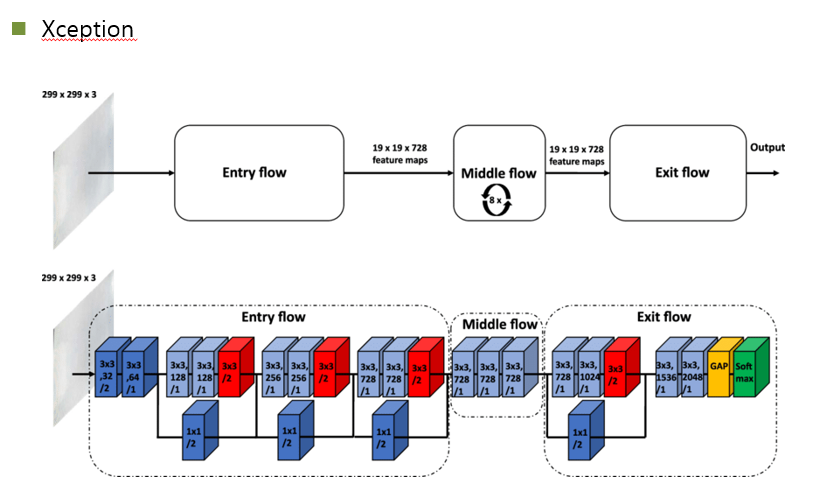

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 사전 학습된 Xception 모델을 활용하여 입력 이미지에 대해 분류를 수행하고,
# Grad-CAM 기법을 적용해 모델이 예측에 집중한 영역을 시각화함.
# 입력 이미지 전처리부터 특징 추출 모델 분리, gradient 기반 중요도 추출, 히트맵 생성 및
# 원본 이미지에 덧씌우는 시각화까지 딥러닝의 해석 가능성을 높이기 위한 일련의 과정을 포함함.
# ------------------------------------------------------------

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 필수 라이브러리 및 모델 불러오기
# 2단계: 입력 이미지 로드 및 전처리
# 3단계: 모델을 이용한 예측 수행
# 4단계: 특징 추출 모델과 분류 모델로 분리
# 5단계: Gradient 기반 히트맵 계산 (Grad-CAM)
# 6단계: 히트맵 시각화 및 원본 이미지와의 오버레이
# ------------------------------------------------------------

# ------------------------------------------------------------
# [1단계] 필수 라이브러리 및 모델 불러오기
# ------------------------------------------------------------

import numpy as np  
# 수치 연산 및 다차원 배열 처리를 위한 라이브러리

import tensorflow as tf  
# 딥러닝 연산 및 텐서 기반 처리 기능 제공 프레임워크

from tensorflow import keras  
# TensorFlow 상위 API로 모델 정의 및 유틸리티 지원

from tensorflow.keras.applications import xception  
# 사전 학습된 Xception 모델 및 관련 전처리/디코딩 유틸리티 제공

from tensorflow.keras.preprocessing import image  
# 이미지 로딩 및 배열 변환 기능 제공 유틸리티

import matplotlib.pyplot as plt  
# 데이터 시각화를 위한 표준 라이브러리

import matplotlib.cm as cm  
# 컬러맵(cmap) 관련 유틸리티 제공 라이브러리

model = xception.Xception(weights='imagenet')  
# ImageNet 데이터로 사전 학습된 Xception 모델 로드

model.summary()  
# 전체 모델 구조 및 파라미터 수 출력

# ------------------------------------------------------------
# [2단계] 입력 이미지 로드 및 전처리
# ------------------------------------------------------------

image_path = './hummingbird.jpg'  
# 분석 대상 이미지 파일 경로 지정

img = image.load_img(image_path, target_size=(299, 299))  
# 입력 이미지를 299x299 크기로 리사이즈 후 로딩

plt.matshow(img)  
# 로드한 이미지를 행렬 형태로 시각화하여 출력

x = image.img_to_array(img)  
# PIL 이미지를 넘파이 배열(H×W×C)로 변환

x = np.expand_dims(x, axis=0)  
# 배치 차원을 추가하여 (1, 299, 299, 3) 형태로 변환

x = xception.preprocess_input(x)  
# Xception 모델 입력 형태에 맞게 전처리 수행 (스케일링 및 색상 변환 포함)

# ------------------------------------------------------------
# [3단계] 모델을 이용한 예측 수행
# ------------------------------------------------------------

preds = model.predict(x)  
# 입력 이미지에 대한 예측 수행 (softmax 확률 반환)

print("예측 결과:", xception.decode_predictions(preds, top=5)[0])  
# 상위 5개 예측 클래스와 클래스명 및 확률을 출력

# ------------------------------------------------------------
# [4단계] 특징 추출 모델과 분류 모델로 분리
# ------------------------------------------------------------

last_conv_layer = model.get_layer("block14_sepconv2_act")  
# Xception의 마지막 합성곱 활성화 층을 가져옴 (Grad-CAM 대상층)

model_1 = keras.Model(model.inputs, last_conv_layer.output)  
# 입력 → 마지막 합성곱 층까지의 특징 추출 모델 구성

input_2 = keras.Input(shape=last_conv_layer.output.shape[1:])  
# 분류 모델 입력용 텐서 정의

x_2 = model.get_layer("avg_pool")(input_2)  
# 전역 평균 풀링 계층 적용

x_2 = model.get_layer("predictions")(x_2)  
# 최종 분류 계층 적용

model_2 = keras.Model(input_2, x_2)  
# 특징 → 클래스 확률 출력 모델 구성

# ------------------------------------------------------------
# [5단계] Gradient 기반 히트맵 계산 (Grad-CAM)
# ------------------------------------------------------------

with tf.GradientTape() as tape:  
    output_1 = model_1(x)  
    # 특징 추출 모델을 통해 마지막 conv 출력 추출
    tape.watch(output_1)  
    # 해당 텐서에 대해 gradient 계산을 가능하도록 설정
    preds = model_2(output_1)  
    # 분류 모델로 예측 확률 계산
    class_id = tf.argmax(preds[0])  
    # 예측 클래스 인덱스 추출
    output_2 = preds[:, class_id]  
    # 예측된 클래스 확률 값만 선택

grads = tape.gradient(output_2, output_1)  
# 선택된 클래스에 대한 특징맵의 gradient 계산

pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))  
# 채널별 평균 gradient 계산 → 중요도 벡터 생성 (식 12.5)

output_1 = output_1.numpy()[0]  
# 텐서를 넘파이 배열로 변환 후 배치 차원 제거

pooled_grads = pooled_grads.numpy()  
# 중요도 벡터를 넘파이로 변환

for i in range(pooled_grads.shape[-1]):  
    output_1[:, :, i] *= pooled_grads[i]  
    # 각 채널의 특징맵에 해당 채널 중요도 가중치 곱셈 (식 12.6)

heatmap = np.mean(output_1, axis=-1)  
# 채널 차원을 평균내어 히트맵 생성

heatmap = np.maximum(heatmap, 0) / np.max(heatmap)  
# 음수 제거 및 정규화 수행하여 0~1 범위로 스케일링

plt.matshow(heatmap)  
# 히트맵 시각화 출력

# ------------------------------------------------------------
# [6단계] 히트맵 시각화 및 원본 이미지와의 오버레이
# ------------------------------------------------------------

img = image.load_img(image_path)  
# 원본 이미지를 다시 불러옴 (해상도 보존 목적)

img = image.img_to_array(img)  
# 이미지를 배열로 변환

heatmap = np.uint8(255 * heatmap)  
# 정규화된 히트맵을 0~255 정수형 범위로 변환

jet = cm.get_cmap("jet")  
# jet 컬러맵을 사용하여 히트맵 색상화 준비

color = jet(np.arange(256))[:, :3]  
# 0~255 범위의 RGB 색상표 정의

color_heatmap = color[heatmap]  
# 히트맵 값을 jet 색상으로 매핑

color_heatmap = keras.preprocessing.image.array_to_img(color_heatmap)  
# 컬러 히트맵을 PIL 이미지로 변환

color_heatmap = color_heatmap.resize((img.shape[1], img.shape[0]))  
# 원본 이미지 크기에 맞게 히트맵 리사이징

color_heatmap = keras.preprocessing.image.img_to_array(color_heatmap)  
# 히트맵을 다시 배열 형태로 변환

overlay_img = color_heatmap * 0.4 + img  
# 히트맵을 원본 이미지에 40% 비율로 덧씌움

overlay_img = keras.preprocessing.image.array_to_img(overlay_img)  
# 최종 오버레이 이미지를 PIL 형식으로 변환

plt.matshow(overlay_img)  
# 오버레이 이미지를 시각화하여 출력


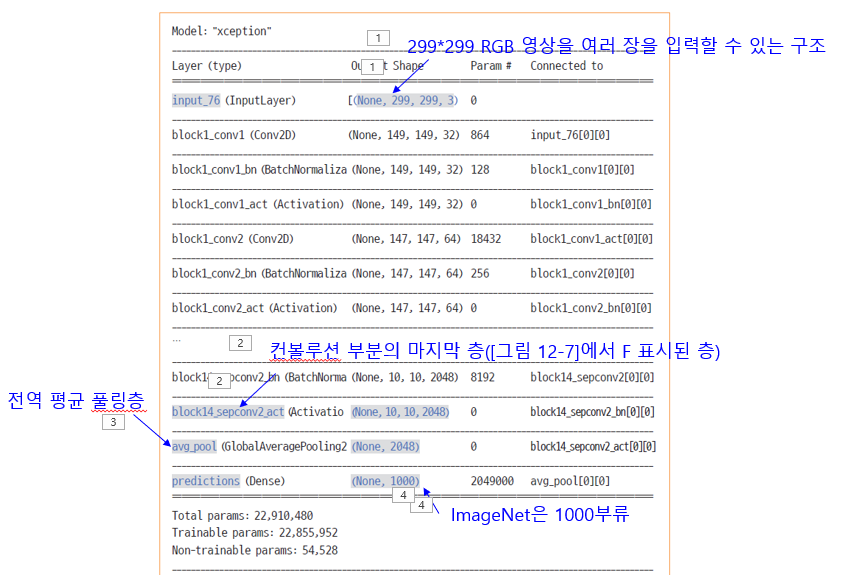

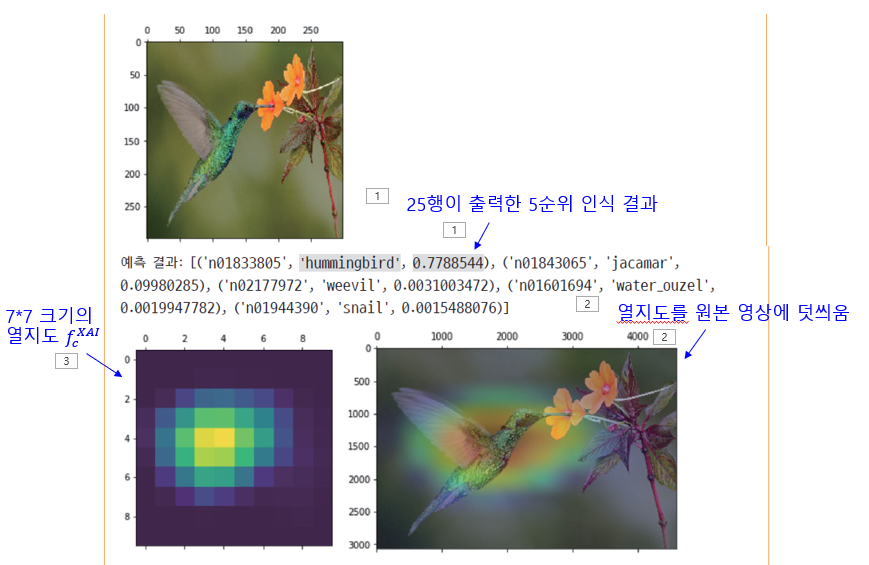